In [1]:
import os

repo_name = 'progetto_GraphColouring_ML26'
repo_url = 'https://github.com/gien-7/progetto_GraphColouring_ML26.git' #importa proprio da github

if not os.path.exists(repo_name):
    !git clone {repo_url}
else:
    print(f"La cartella '{repo_name}' è già caricata")

Cloning into 'progetto_GraphColouring_ML26'...
remote: Enumerating objects: 80, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 80 (delta 30), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (80/80), 4.33 MiB | 13.56 MiB/s, done.
Resolving deltas: 100% (30/30), done.


In [2]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 12.5 MB/s eta 0:00:0000:0100:01


In [3]:
# 1. Base framework first
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, Dataset, DataLoader
import torch.utils.data as data

# 2. Extensions next
from torch_geometric.nn import SAGEConv

# 3. Standard data science libraries
import csv
import random
import numpy as np
import pandas as pd
import time, copy
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

In [4]:
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

#### Si definisce una funzione per settare tutti i seed a un valore (randomico o meno che sia), quindi il seed relativo a pytorch, normale, ecc...

In [5]:
def universal_seed(seed = 42):
    """Imposta il seed per la riproducibilità su Python, NumPy, PyTorch e ambiente."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Determinismo per gli algoritmi pytorch:
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"Seed impostato su {seed}")

In [6]:
seed = 42
universal_seed(seed)

Seed impostato su 42


#Preprocessing

In [7]:
file1 = 'progetto_GraphColouring_ML26/g6.col'  # queen9x9
file2 = 'progetto_GraphColouring_ML26/g17.col'  # miles750

df_g6 = pd.read_csv(file1, sep='\s+', skiprows=4, usecols=[1,2], names=['node1','node2'])
df_g17 = pd.read_csv(file2, sep='\s+', skiprows=4, usecols=[1,2], names=['node1','node2'])

print('Shape g6.col  : ',df_g6.shape)
print('Shape g17.col : ',df_g17.shape)

Shape g6.col  :  (2112, 2)
Shape g17.col :  (4226, 2)


# Queen9x9

In [8]:
print(df_g6) #ogni donna puo interagire con le caselle che ha intorno (al bordo ha meno caselle)
#node 1 ti da la casella di partenza, node 2 quelle a cui è collegata
#il filw contiene quindi tutti gli edges

      node1  node2
0         1     11
1         1     21
2         1     31
3         1     41
4         1     51
...     ...    ...
2107     81     21
2108     81     18
2109     81     11
2110     81      9
2111     81      1

[2112 rows x 2 columns]


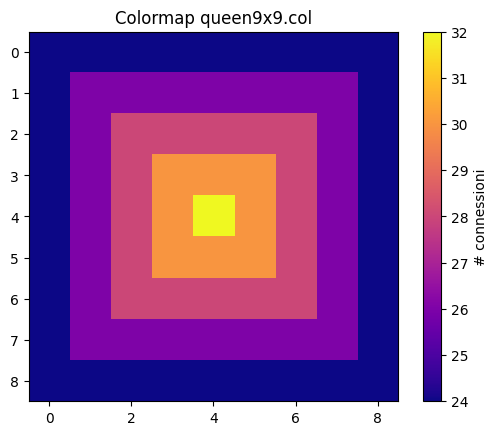

In [9]:
#meno sei al centro meno connesioni hai
unique, counts = np.unique(df_g6['node1'].values, return_counts=True)  # non cambierebbe nulla se operassi invece su node2 per simmetria
# unique prende una volta sola gli elementi, values trasforma in array
queen_intensity_queen = counts.reshape(9,9) #trasformo l'arary in griglia

plt.imshow(queen_intensity_queen, cmap='plasma')
plt.colorbar(label = '# connessioni')
plt.title('Colormap queen9x9.col')
plt.show()

In [10]:
index_grid = (unique-1).reshape(9,9) #indice di ogni nodo, scacchiera
index_grid

array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8],
       [ 9, 10, 11, 12, 13, 14, 15, 16, 17],
       [18, 19, 20, 21, 22, 23, 24, 25, 26],
       [27, 28, 29, 30, 31, 32, 33, 34, 35],
       [36, 37, 38, 39, 40, 41, 42, 43, 44],
       [45, 46, 47, 48, 49, 50, 51, 52, 53],
       [54, 55, 56, 57, 58, 59, 60, 61, 62],
       [63, 64, 65, 66, 67, 68, 69, 70, 71],
       [72, 73, 74, 75, 76, 77, 78, 79, 80]])

**Data augmentation sfruttando invarianze per simmetria del problema**

In [11]:
from torch_geometric.utils import to_undirected

def build_edges_from_df(col1, col2):
  src = torch.tensor(col1.values, dtype=torch.long)  # nodo 1, formato long perchè va cosi
  dst = torch.tensor(col2.values, dtype=torch.long)
  edge_index = torch.stack([src, dst], dim=0)
  return to_undirected(edge_index)  # grafo non orientato

#data aigmentation qui non avrebbe molto senso ma può essere utile per evitare di memorizzare soluzioni sbagliata (DA VALUTARE)
def transform_node_index(x, y, k_rot, do_flip=False): #combinazione di rotazione e riflessione (8)
    if do_flip:
        x=-x
    for _ in range(k_rot):
        # Rotazione 90°: (x, y) -> (y, -x)
        x, y = y, -x
    pos_n_aug = torch.stack([x, y], dim=1) #gia in tensore
    return pos_n_aug

def transform_edges(serie, k_rot, do_flip=False): #cambia la mappa degli edges in funzione della rotazione dei nodi
  idx = serie-1  # da 1->81 a 0->80
  r = idx // 9
  c = idx % 9
  if do_flip:
    c = 8 - c
  for _ in range(k_rot):
    r, c = c, 8 - r
  return (r * 9 + c) +1 #da 0->80 a 1->81

In [12]:
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data

class QueenGraphGenerator(Dataset):
    def __init__(self, X, df, AUGMENT=False):
      super().__init__()
      self.X = X  # intenità nodi
      self.df = df
      self.AUGMENT = AUGMENT

    def __len__(self):  # Ritorna la dimensione del dataset
      return len(self.X)

    def __getitem__(self, idx): #ritorna l'elemento idx del dataset
      intensity = self.X[idx].copy()
      node_list = self.df[idx].copy() # copy() per evitare che augment modifichi i dati originali
      col1_label = (self.df[idx].columns)[0]
      col2_label = (self.df[idx].columns)[1]

      k_rot = 0
      do_flip = False

      rows, cols = np.indices((9, 9)) #ripete numeri in colonne e righe
      rows = rows.reshape(-1) # [0,0,0...1,1,1...n,n,n]
      cols = cols.reshape(-1) # [0,1,2...,0,1,2,...]
      values = intensity[rows, cols].astype(np.float32)  # sarà unidimensionale avendo flattenato, è strano ma vabe, deve essere float32

      # data.pos contiene le coordinate geometriche non normalizzate delle connessioni sul piano 9x9.
      pos = torch.tensor(np.stack([rows, cols], axis=1), dtype=torch.float) # su asse 1 è sulle colonne, 81x2, coordinate possibili
      pos_n = (pos/8.) * 2. - 1.  #normalizza da -1 a 1

      '''
      L'augmentation ha il fine di cambiare l'ordine degli indici
      quindi magari [0][2]=(2) -> [8][6]=(79)'. Segue che, oltre a ruotare
      il tensore delle posizioni, dovrò anche cambiare i vari edges:
      la nuova posizione (79)' eredita le connessioni di (2), e viceversa per (2)'.
      D'altro canto, la feature d'intensity non varia per simmetria del problema!
      Per formalismo è stato fatto lo stesso.
      '''

      if self.AUGMENT: # solo in training!!
        k_rot = np.random.randint(0, 4)
        do_flip = np.random.choice([True, False])
        x_coords = pos_n[:, 0].clone()
        y_coords = pos_n[:, 1].clone()
        pos_n = transform_node_index(x_coords, y_coords, k_rot, do_flip)

        node_list[col1_label] = transform_edges(node_list[col1_label].values, k_rot, do_flip)
        node_list[col2_label] = transform_edges(node_list[col2_label].values, k_rot, do_flip)

        # aggiungi rumore gaussiano (noise injetion) con std = 0.01 (smanettare su questo magari?)
        pos_n = pos_n + torch.randn_like(pos_n) * 0.01


      # Creo vettore x contenente
      value = torch.tensor(values/values.sum(), dtype=torch.float).view(-1, 1) #trasforma l'array delle intensità in 2d con la famosa dim dummy.
      x = torch.cat([value], dim=1)  # torch vuole dimensione dummy delle label di x, ritorna coppie

      # L'output di build_knn_edges del tipo torch.Tensor(2, (num_nodes x k_eff)), interi int64
      edge_index = build_edges_from_df(node_list[col1_label]-1, node_list[col2_label]-1)
      # In input le due serie relative al dataframe, scalate di 1 (anzichè fare da 1->9 fa 0->8)

      # Problema unsupervised, uso y dummy pari a indici delle caselle
      #tensor_label = torch.arange(81, dtype=torch.long) #non è niente perche y prende i valori veri che in questo caso non ci sono. (possibile errore)

      return Data(x=x, edge_index=edge_index, y=None, pos=pos_n) #x è coordinata con intensità

In [13]:
#se sei confuso con le shape prova qui, non runna...
'''rows = rows.reshape(-1)
cols = cols.reshape(-1)
print(np.stack([rows, cols], axis=0)) #dim 0 numero di array
print(np.stack([rows, cols], axis=1)) #dim 1 righe degli array, dim 2 colonne'''

'rows = rows.reshape(-1)\ncols = cols.reshape(-1)\nprint(np.stack([rows, cols], axis=0)) #dim 0 numero di array\nprint(np.stack([rows, cols], axis=1)) #dim 1 righe degli array, dim 2 colonne'

In [14]:
queen_df = df_g6.copy()
#N = 32 # randomizzerò 32 volte per epoca, sullo stesso grafo di partenza
N= 1
multi_X = [queen_intensity_queen] * N
multi_df = [queen_df] * N

queen_dataset_queen = QueenGraphGenerator(multi_X, multi_df, AUGMENT=False) #chiedi per sicurezza
#queen_loader_queen = DataLoader(queen_dataset_queen, batch_size=int(N/4), shuffle=True, num_workers=2, pin_memory=True, drop_last=True) #eventualmente batch_size=2
queen_loader_queen = DataLoader(queen_dataset_queen, batch_size= 1, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)

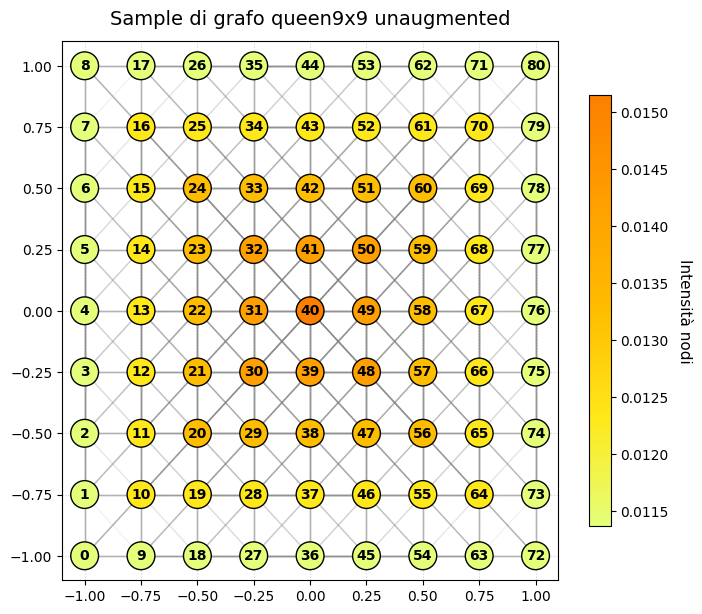

In [15]:
from torch_geometric.utils import to_networkx
import networkx as nx

data = queen_dataset_queen[0]
G = to_networkx(data, to_undirected=True)
pos_dict = {i: data.pos[i].numpy() for i in range(data.num_nodes)}

fig, ax = plt.subplots(figsize=(8, 7))

nodes = nx.draw_networkx_nodes(G, pos_dict,
                               ax=ax,
                               node_size=400,
                               node_color=data.x[:, 0].numpy(),
                               cmap='Wistia',
                               edgecolors='black')

nx.draw_networkx_edges(G, pos_dict, ax=ax, alpha=0.1, edge_color='gray')
nx.draw_networkx_labels(G, pos_dict, ax=ax,
                        font_size=10,
                        font_family='sans-serif',
                        font_weight='bold')

cbar = fig.colorbar(nodes, shrink = 0.8, ax=ax)
cbar.set_label('Intensità nodi', rotation=270, labelpad=17, fontsize=11)

ax.set_axis_on()
ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)

x_coords = data.pos[:, 0].numpy()
y_coords = data.pos[:, 1].numpy()
ax.set_xlim(x_coords.min() - 0.1, x_coords.max() + 0.1)
ax.set_ylim(y_coords.min() - 0.1, y_coords.max() + 0.1)

ax.grid(True, linestyle=':', alpha=0.6)
ax.set_title("Sample di grafo queen9x9 unaugmented", fontsize=14, pad=12)

plt.show()

In [16]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print('Using',device, 'device')

Using cuda device


## Modello GNN
 Per evitare eccessiva simmetria e uguaglianza nelle features dei nodi usiamo **embedding learnable**. Alle features geometriche (x, y, intensità) aggiungiamo embedding casuale di dim 32 ad ogni nodo. La differenza con il classico embedding delle GNN è che viene aggiornato in ogni epoca pesandolo in base alla loss (emb = self.node_emb(node_ids) nel forward). Quindi all'inizio di ogni epoca ho le stesse features geometriche ma il resto dell'embedding è ottimizzato, come lo sono i pesi dei layer della GNN.

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class GNN_net(nn.Module):
    def __init__(self, c, N, i_dim=1):
        super().__init__()

        self.N = N
        self.node_emb = nn.Embedding(N, 32) # **

        self.conv1 = SAGEConv(i_dim + 32, 64)
        self.conv2 = SAGEConv(64, 64)

        self.fc = nn.Linear(64, c)

    def forward(self, data):
        x = data.x
        edge_index = data.edge_index

        node_ids = torch.arange(
            data.num_nodes,
            device=x.device
        ) % self.N #crea un array con 81 x batch_size e lo divide in una sequenza 0....80, 0....80,....

        emb = self.node_emb(node_ids) #emb.shape = [batch_size x 81, 32], qui sto pesando

        x_combined = torch.cat([x, emb], dim=-1) #unisco embedding learnable e features geometriche

        x_out = F.relu(self.conv1(x_combined, edge_index))
        x_out = F.relu(self.conv2(x_out, edge_index))

        logits = self.fc(x_out)

        return F.softmax(logits, dim=-1)


In [18]:
model = GNN_net(c=9, N=81).to(device) #abbiamo esperienza di casi con 12 colori e 0 conflitti
print(model)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Numero di parametri trainabili:", num_params)

GNN_net(
  (node_emb): Embedding(81, 32)
  (conv1): SAGEConv(33, 64, aggr=mean)
  (conv2): SAGEConv(64, 64, aggr=mean)
  (fc): Linear(in_features=64, out_features=9, bias=True)
)
Numero di parametri trainabili: 15721


In [19]:
def potts_loss(p, edge_index):
    row, col = edge_index
    mask = row < col # evita doppio conteggio
    row, col = row[mask], col[mask]

    return (p[row] * p[col]).sum(dim=1).mean()

def count_conflicts(colors, edge_index):
    row, col = edge_index
    mask = row < col
    row, col = row[mask], col[mask]
    return (colors[row] == colors[col]).sum().item()

In [20]:
# prova su un solo batch
batch = next(iter(queen_loader_queen))
batch = batch.to(device) # sposta tutti i tensori della Batch PyG sulla device

prob = model(batch)

print('output shape: ', prob.shape)
print('num grafi nella batch: ', batch.num_graphs)
print('num nodi nella batch: ', batch.num_nodes)

# loss
loss = potts_loss(prob, batch.edge_index)

print('loss: ', loss.item()) #.item() per prendere il numero, sarebbe un tensore

colors = prob.argmax(dim=1)
conflicts = count_conflicts(colors, batch.edge_index)
print('numero di conflitti: ', conflicts) #da dividere per batch_size

output shape:  torch.Size([81, 9])
num grafi nella batch:  1
num nodi nella batch:  81
loss:  0.11352384835481644
numero di conflitti:  745


Dobbiamo capire cosa fare con augmentation. Non sembra migliorare le cose e ovviamente vanno diminuite le epoche altrimenti ci mette più di 30 min. Prima di runnare modifica la cella delle batches (ad esempio metti N=1 e batch_size=1). Ovviamente il numero di conflitti va diviso per il numero di grafi nelle batches.

In [21]:
#training loop

optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)

model.train()

for epoch in range(1000):

  for batch_idx, batch in enumerate(queen_loader_queen): #batch_idx per ora non serve ma non si sa mai

    batch = batch.to(device)
    optimizer.zero_grad() #sennò somma i pesi

    p = model(batch)


    potts = potts_loss(p, batch.edge_index)

    entropy = -(p * torch.log(p + 1e-9)).sum(dim=1).mean()


    #l'entropia forza la rete ad esplorare.
    loss = potts - 0.01 * entropy

    loss.backward()
    optimizer.step()

    if epoch % 100 == 0 or epoch == 1000 - 1:
        colors = p.argmax(dim=1)
        conflicts = count_conflicts(colors, batch.edge_index)
        max_prob = p.max(dim=1).values.mean().item() #massima probabilità di p

        print(epoch, f"Loss Tot: {loss.item():.4f}", f"Potts: {potts.item():.4f}", f"Conf: {conflicts}", f"MaxProb: {max_prob:.4f}")



0 Loss Tot: 0.0917 Potts: 0.1135 Conf: 745 MaxProb: 0.1446
100 Loss Tot: 0.0891 Potts: 0.1111 Conf: 118 MaxProb: 0.1246
200 Loss Tot: 0.0890 Potts: 0.1109 Conf: 148 MaxProb: 0.1322
300 Loss Tot: 0.0854 Potts: 0.1053 Conf: 121 MaxProb: 0.2364
400 Loss Tot: 0.0659 Potts: 0.0790 Conf: 55 MaxProb: 0.4991
500 Loss Tot: 0.0430 Potts: 0.0481 Conf: 40 MaxProb: 0.8090
600 Loss Tot: 0.0309 Potts: 0.0327 Conf: 31 MaxProb: 0.9475
700 Loss Tot: 0.0268 Potts: 0.0276 Conf: 28 MaxProb: 0.9777
800 Loss Tot: 0.0260 Potts: 0.0267 Conf: 27 MaxProb: 0.9739
900 Loss Tot: 0.0254 Potts: 0.0260 Conf: 27 MaxProb: 0.9777
999 Loss Tot: 0.0253 Potts: 0.0258 Conf: 27 MaxProb: 0.9776


## Post Processing

In [22]:
# Post-processing: Greedy init + Tabu Search
def greedy_init(colors_init, edge_index, prob, num_colors):
    """
    Greedy repair veloce: sistema i nodi conflittuali assegnando
    il colore libero con probabilità GNN più alta.
    Usato come warm-start prima della tabu search.
    """
    row, col = edge_index
    colors = colors_init.clone()

    for _ in range(500):
        mask = row < col
        r, c = row[mask], col[mask]
        conflict_mask  = colors[r] == colors[c]
        if conflict_mask.sum() == 0:
            break
        conflict_nodes = torch.cat([r[conflict_mask], c[conflict_mask]]).unique()
        for node in conflict_nodes[torch.randperm(len(conflict_nodes))].tolist():
            neighbors = set(
                colors[col[row == node]].tolist() +
                colors[row[col == node]].tolist()
            )
            free = [k for k in range(num_colors) if k not in neighbors]
            if free:
                colors[node] = max(free, key=lambda k: prob[node, k].item())

    return colors


def tabu_search(colors_init, edge_index, prob, num_colors,
                max_iter=5000, tabu_tenure=15, n_restarts=10):
    """
    Tabu Search per graph coloring.

    Ad ogni iterazione:
      1. Trova tutti i nodi conflittuali
      2. Per ciascuno valuta tutti i colori possibili (mossa = (nodo, nuovo_colore))
      3. Sceglie la mossa che minimizza i conflitti, anche se peggiora (uscita dal min locale)
      4. Vieta quella mossa per `tabu_tenure` iterazioni (tabu list)
      5. Eccezione: se la mossa porta al miglior risultato in assoluto (aspiration criterion),
         viene accettata anche se tabu
      6. Riparte da greedy_init per n_restarts tentativi indipendenti
    """
    row, col = edge_index
    mask_sym  = row < col
    r_s, c_s  = row[mask_sym], col[mask_sym]

    best_colors    = colors_init.clone()
    best_conflicts = count_conflicts(best_colors, edge_index)

    for restart in range(n_restarts):
        if best_conflicts == 0:
            break

        # warm-start greedy ad ogni restart
        colors    = greedy_init(colors_init, edge_index, prob, num_colors)
        tabu_list = {}   # (nodo, colore) -> iterazione in cui scade il divieto
        curr_best = count_conflicts(colors, edge_index)

        for it in range(max_iter):
            conf_mask      = colors[r_s] == colors[c_s]
            conflict_nodes = torch.cat([r_s[conf_mask], c_s[conf_mask]]).unique()

            if len(conflict_nodes) == 0:
                break

            best_move       = None
            best_move_conf  = float('inf')

            # esplora tutte le mosse sui nodi conflittuali
            for node in conflict_nodes.tolist():
                old_color = colors[node].item()
                for new_color in range(num_colors):
                    if new_color == old_color:
                        continue

                    colors[node] = new_color
                    new_conf = count_conflicts(colors, edge_index)
                    colors[node] = old_color   # ripristina

                    is_tabu = tabu_list.get((node, new_color), 0) > it

                    # accetta se: non tabu E migliora la mossa corrente
                    #          O: tabu ma batte il best assoluto (aspiration)
                    if (not is_tabu and new_conf < best_move_conf) or \
                       (is_tabu and new_conf < best_conflicts):
                        best_move      = (node, new_color)
                        best_move_conf = new_conf

            if best_move is None:
                # nessuna mossa valida: kick casuale per sbloccarsi
                node      = conflict_nodes[torch.randint(len(conflict_nodes), (1,))].item()
                new_color = torch.randint(num_colors, (1,)).item()
                best_move = (node, new_color)
                best_move_conf = count_conflicts(
                    colors.clone().index_fill_(0, torch.tensor([node]), new_color),
                    edge_index
                )

            # applica la mossa migliore
            node, new_color = best_move
            old_color       = colors[node].item()
            colors[node]    = new_color

            # aggiorna tabu list: vieta di tornare al vecchio colore su quel nodo
            tabu_list[(node, old_color)] = it + tabu_tenure

            # aggiorna best globale
            if best_move_conf < best_conflicts:
                best_conflicts = best_move_conf
                best_colors    = colors.clone()

            curr_best = best_move_conf

        # piccola variazione di tenure tra restart per diversificare
        tabu_tenure = max(5, tabu_tenure - 1)

    return best_colors, best_conflicts

In [23]:
model.eval()
with torch.no_grad():
    single_dataset = QueenGraphGenerator([queen_intensity_queen], [queen_df], AUGMENT=False)
    single_loader  = DataLoader(single_dataset, batch_size=1)
    single_batch   = next(iter(single_loader)).to(device)

    prob           = model(single_batch)
    colors_raw     = prob.argmax(dim=1).cpu()
    prob_cpu       = prob.cpu()
    edge_index_cpu = single_batch.edge_index.cpu()

num_colors = prob_cpu.shape[1]
print(f"Conflitti prima del post-processing: {count_conflicts(colors_raw, edge_index_cpu)}")


colors_fixed, final_conflicts = tabu_search(
    colors_raw, edge_index_cpu, prob_cpu, num_colors,
    max_iter=2000, tabu_tenure=15, n_restarts=2 #abbasate le iterazione per volecita
)

print(f"Conflitti dopo il post-processing: {final_conflicts}")
if final_conflicts == 0:
    print(f"✅ Colorazione valida! Colori usati: {colors_fixed.unique().shape[0]}")
else:
    print(f"⚠️  Rimangono {final_conflicts} conflitti")

Conflitti prima del post-processing: 27
Conflitti dopo il post-processing: 6
⚠️  Rimangono 6 conflitti


📊 Verifica geometrica: 6 conflitti rilevati.
🎨 Colori unici utilizzati sulla scacchiera: 9



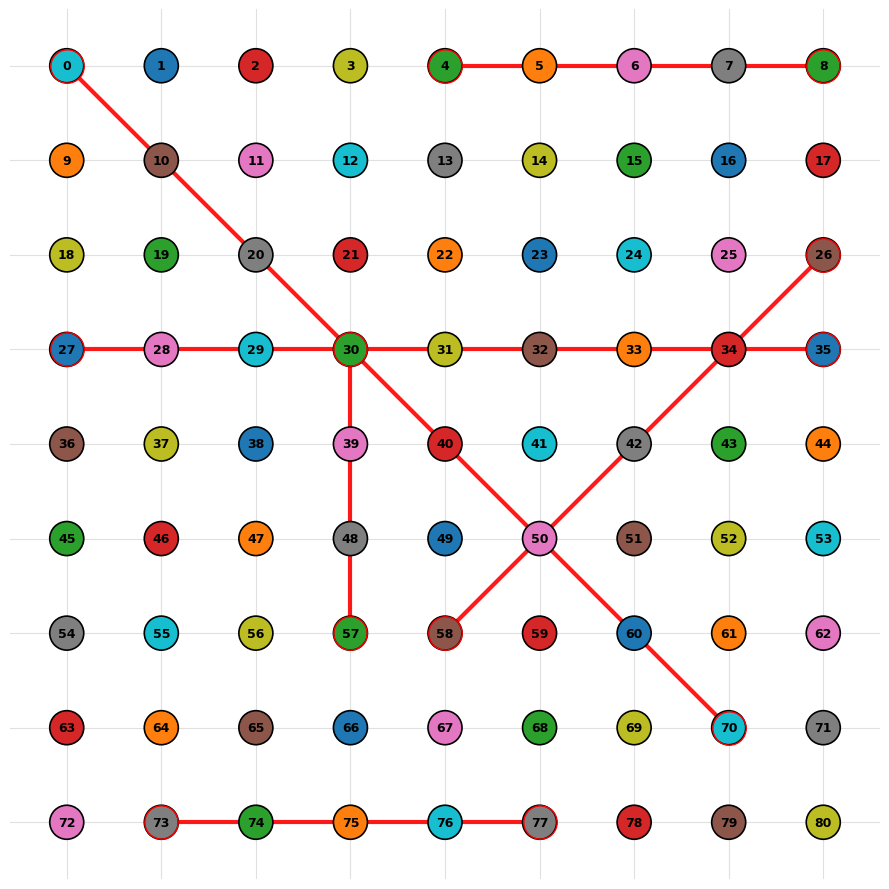

In [24]:
# 1. Assicuriamoci che il modello sia in eval e i vettori siano numpy
model.eval()
colors_post_pp = colors_fixed.cpu().numpy()  # Array di 81 elementi (0-80)
ei_cpu = edge_index_cpu.numpy()

# 2. Ricostruiamo la scacchiera 9x9 corretta
# Il nodo 0 deve andare in alto a sinistra (riga 0, colonna 0), il nodo 80 in basso a destra
grid_colors = colors_post_pp.reshape(9, 9)

# 3. Identifichiamo i conflitti reali sulla griglia spaziale
row, col = ei_cpu[0], ei_cpu[1]
mask = row < col
row_m, col_m = row[mask], col[mask]
conflicts_indices = np.where(colors_post_pp[row_m] == colors_post_pp[col_m])[0]
num_conflicts = len(conflicts_indices)

print(f"📊 Verifica geometrica: {num_conflicts} conflitti rilevati.")
print(f"🎨 Colori unici utilizzati sulla scacchiera: {len(np.unique(colors_post_pp))}\n")

# 4. Creazione del disegno geometrico esatto
fig, ax = plt.subplots(figsize=(9, 9), facecolor='white')

# Generiamo le coordinate reali (x, y) per ognuno degli 81 nodi sulla scacchiera
# x va da 0 a 8 (colonne), y va da 8 a 0 (righe, invertite per visualizzarle dall'alto in basso)
x_coords = np.array([i % 9 for i in range(81)])
y_coords = np.array([8 - (i // 9) for i in range(81)])

# Tracciamo una linea di griglia leggerissima di sfondo per dare l'idea della scacchiera (stile sketch)
for i in range(9):
    ax.axhline(y=i, color='#E0E0E0', linestyle='-', linewidth=0.8, zorder=1)
    ax.axvline(x=i, color='#E0E0E0', linestyle='-', linewidth=0.8, zorder=1)

# Se esistono conflitti, disegniamo una linea rossa tra i nodi incriminati
if num_conflicts > 0:
    for idx in conflicts_indices:
        n1, n2 = row_m[idx], col_m[idx]
        ax.plot([x_coords[n1], x_coords[n2]], [y_coords[n1], y_coords[n2]], 
                color='red', linewidth=3, alpha=0.9, zorder=2)

# Disegniamo i nodi come cerchi perfetti con i colori accesi di Set3
scatter = ax.scatter(x_coords, y_coords, 
                     c=colors_post_pp, 
                     cmap=plt.cm.tab10, 
                     s=600,                 # Dimensione del cerchio
                     edgecolors='black',    # Bordo nero marcato
                     linewidths=1.2,        # Spessore del bordo
                     zorder=3)              # Mette i nodi sopra le linee di griglia

# Inseriamo i numeri identificativi dei nodi (0-80) al centro esatto di ogni cerchio
for i in range(81):
    ax.text(x_coords[i], y_coords[i], str(i), 
            color='black', 
            fontsize=9, 
            fontweight='bold',
            ha='center', 
            va='center', 
            zorder=4)

# Evidenziamo i nodi in conflitto con un cerchio rosso esterno se ce ne sono
for idx in conflicts_indices:
    for node in (row_m[idx], col_m[idx]):
        ax.plot(x_coords[node], y_coords[node], 'ro', markersize=24, fillstyle='none', linewidth=2, zorder=5)

# ── PULIZIA TOTALE (NIENTE BORDI, NIENTE ASSI, NIENTE BARRE) ────────────
ax.set_axis_off()           # Elimina assi e scritte dei ticks
plt.box(True)              # Rimuove il quadrato nero di contorno
ax.set_xlim(-0.6, 8.6)      # Centra il disegno lasciando un leggero margine interno
ax.set_ylim(-0.6, 8.6)

plt.tight_layout()
plt.show()



## Studio condizioni iniziale

In [25]:
#Setup valori 
C_VALUES   = list(range(8, 13))   
SEEDS      = [42, 123, 7, 99, 2025]
N_EPOCHS   = 1000
LOG_EVERY  = 50
N_AUG      = 1    # copie augmentate per loader
BATCH_SIZE = 1
N_RESTART_PP = 2
ITER_PP = 1000

Save_Data = True #se Treu genera file con dati salvati !!attenzione sovrascrive se i file esistono gia

In [26]:
# Studio condizioni iniziali — Queen
# all_results[c][seed] = {log, conf_before_pp, conf_after_pp, colors, time_s}
all_results_queen  = {c: {} for c in C_VALUES}
total_runs_queen   = len(C_VALUES) * len(SEEDS)
run_idx_queen      = 0

# ── DATASET DI RIFERIMENTO (Estratto una volta sola fuori dai loop) ───
# Visto che AUGMENT=False, generiamo direttamente il singolo oggetto Data di PyG
base_dataset_queen = QueenGraphGenerator([queen_intensity_queen], [queen_df], AUGMENT=False)
graph_ref_queen = base_dataset_queen[0]

for c in C_VALUES:
    for seed in SEEDS:
        run_idx_queen += 1
        print(f"\n{'═'*58}")
        print(f"   Run {run_idx_queen}/{total_runs_queen}  |  c={c}  seed={seed}")
        print(f"{'═'*58}")

        # ── riproducibilità ──────────────────────────────────────────
        universal_seed(seed)

        # ── caricamento grafo unico sul device (una volta per run) ────
        batch = graph_ref_queen.to(device)

        # ── modello ──────────────────────────────────────────────────
        model_run = GNN_net(c=c, N=81).to(device)
        optimizer = torch.optim.Adam(model_run.parameters(), lr=2e-4)
        model_run.train()

        # log: lista di (epoch, loss_tot, potts, n_conflicts, max_prob)
        log = []
        t0  = time.time()
        best_conf_queen = float('inf')
        best_model_state_queen = None

        for epoch in range(N_EPOCHS):
            optimizer.zero_grad()

            p       = model_run(batch)
            potts   = potts_loss(p, batch.edge_index)
            entropy = -(p * torch.log(p + 1e-9)).sum(dim=1).mean()
            loss    = potts - 0.01 * entropy

            loss.backward()
            optimizer.step()

            # ── logging e controllo conflitti (allineato a LOG_EVERY) ──
            if epoch % LOG_EVERY == 0 or epoch == N_EPOCHS - 1:
                with torch.no_grad():
                    colors_b  = p.argmax(dim=1)
                    # NOTA: Rimosso .item() se count_conflicts restituisce già int
                    conf_b    = count_conflicts(colors_b, batch.edge_index)
                    max_prob  = p.max(dim=1).values.mean().item()

                # Verifichiamo se abbiamo trovato una configurazione migliore
                if conf_b < best_conf_queen:
                    best_conf_queen = conf_b
                    best_model_state_queen = copy.deepcopy(model_run.state_dict())

                log.append((epoch, loss.item(), potts.item(), conf_b, max_prob, best_conf_queen))

                if epoch % 250 == 0 or epoch == N_EPOCHS - 1:
                    print(f"   ep {epoch:4d} | loss {loss.item():.4f} "
                          f"| potts {potts.item():.4f} "
                          f"| conf {conf_b:4d} "
                          f"| maxP {max_prob:.3f}")
                
                # ── early stopping (CORRETTO: dentro il blocco di log) ──────
                if conf_b == 0:
                    print(f"   ✅ 0 conflitti raggiunti all'epoca {epoch} — stop anticipato")
                    break

        # Carica i pesi con il minor numero di conflitti 
        if best_model_state_queen is not None:
            model_run.load_state_dict(best_model_state_queen)
            print(f"   📥 Caricato il miglior modello della run (conflitti minimi nel train: {best_conf_queen})")

        # ── valutazione su grafo singolo (no augment) ─────────────────
        model_run.eval()
        with torch.no_grad():
            # Usiamo direttamente il batch già presente sul device
            prob      = model_run(batch)
            colors_raw = prob.argmax(dim=1).cpu()
            prob_cpu   = prob.cpu()
            ei_cpu     = batch.edge_index.cpu()

        conf_before = count_conflicts(colors_raw, ei_cpu)

        # ── post-processing tabu ──────────────────────────────────────
        if conf_before == 0:
            colors_fixed, conf_after = colors_raw, 0
            print("   ⚡ 0 conflitti — post-processing saltato")
        else:
            colors_fixed, conf_after = tabu_search(
                colors_raw, ei_cpu, prob_cpu, c,
                max_iter=ITER_PP, tabu_tenure=15, n_restarts=N_RESTART_PP
            )

        elapsed = time.time() - t0

        print(f"\n   ✔  {elapsed:.1f}s  |  "
              f"conflitti: {conf_before} → {conf_after} (dopo Post-processing)")

        all_results_queen[c][seed] = {
            'log':            log,
            'conf_before_pp': conf_before,
            'conf_after_pp':  conf_after,
            'colors':         colors_fixed,
            'time_s':         elapsed,
        }

print("\nRun completate!!")

if Save_Data:
    with open('Risultati_Finale_queen.csv', 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(['C_Value', 'Seed', 'Conf_Before_PP', 'Conf_After_PP', 'Time_Seconds'])
        
        for c, seeds in all_results_queen.items():
            for seed, res in seeds.items():
                writer.writerow([c, seed, res['conf_before_pp'], res['conf_after_pp'], res['time_s']])
    print("💾 Risultati salvati correttamente in 'Risultati_Finale_queen.csv'")


══════════════════════════════════════════════════════════
   Run 1/25  |  c=8  seed=42
══════════════════════════════════════════════════════════
Seed impostato su 42
   ep    0 | loss 0.1075 | potts 0.1281 | conf  428 | maxP 0.160
   ep  250 | loss 0.1030 | potts 0.1232 | conf  219 | maxP 0.193
   ep  500 | loss 0.0478 | potts 0.0509 | conf   50 | maxP 0.897
   ep  750 | loss 0.0353 | potts 0.0357 | conf   37 | maxP 0.991
   ep  999 | loss 0.0340 | potts 0.0344 | conf   36 | maxP 0.980
   📥 Caricato il miglior modello della run (conflitti minimi nel train: 36)

   ✔  63.2s  |  conflitti: 36 → 22 (dopo Post-processing)

══════════════════════════════════════════════════════════
   Run 2/25  |  c=8  seed=123
══════════════════════════════════════════════════════════
Seed impostato su 123
   ep    0 | loss 0.1049 | potts 0.1257 | conf  239 | maxP 0.144
   ep  250 | loss 0.0923 | potts 0.1081 | conf   94 | maxP 0.408
   ep  500 | loss 0.0468 | potts 0.0484 | conf   48 | maxP 0.943
   ep

### Grafici stat

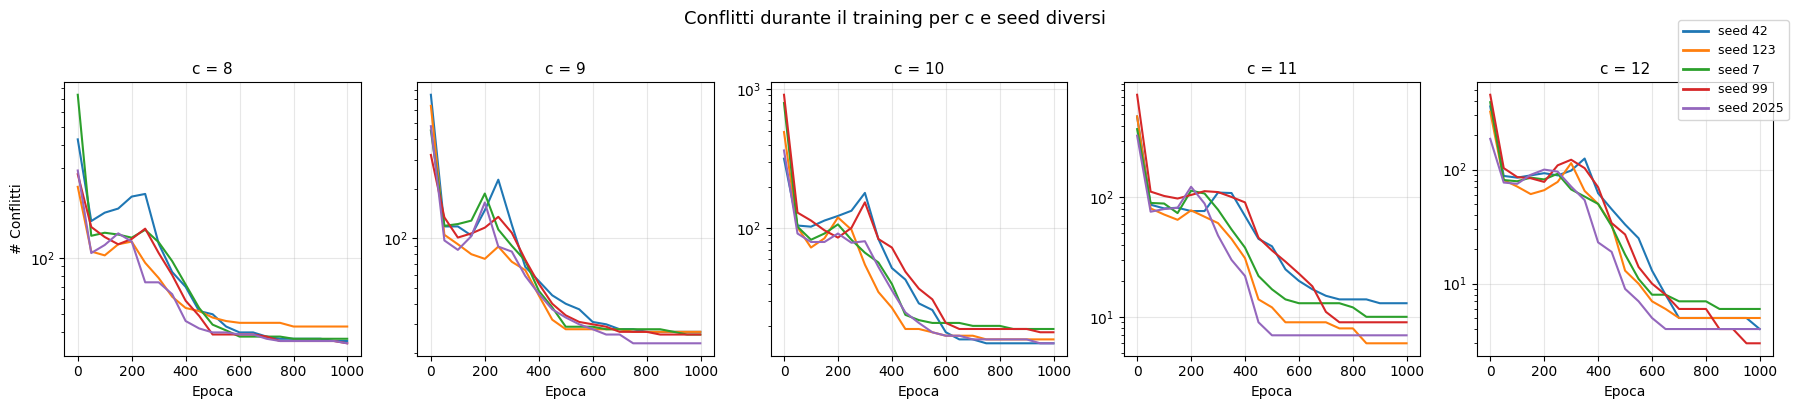

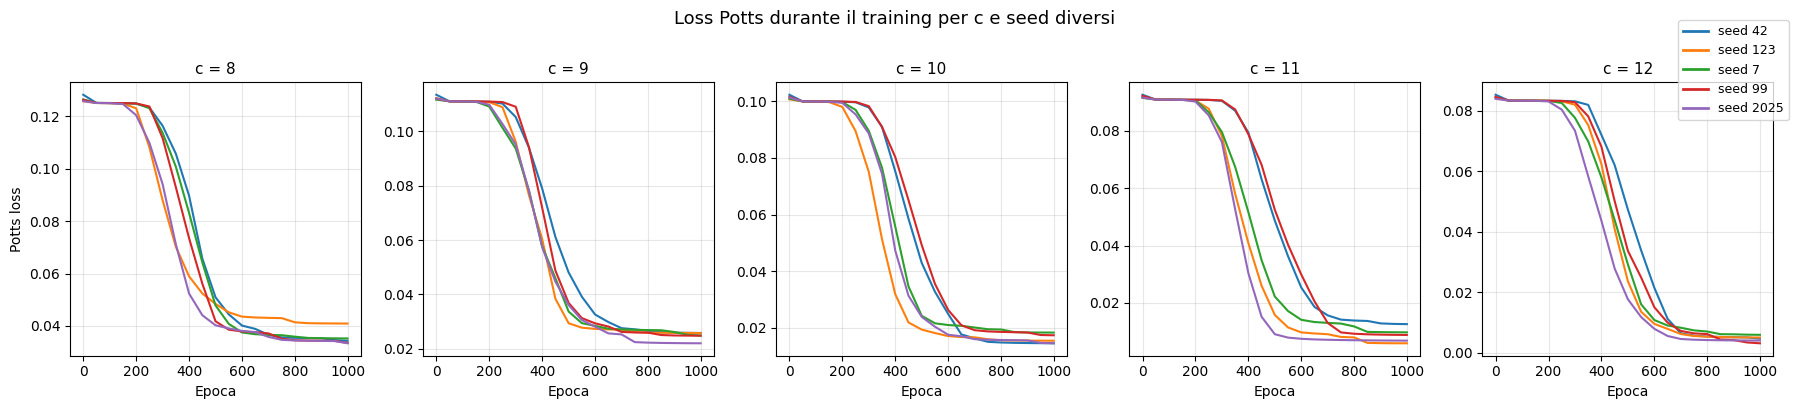

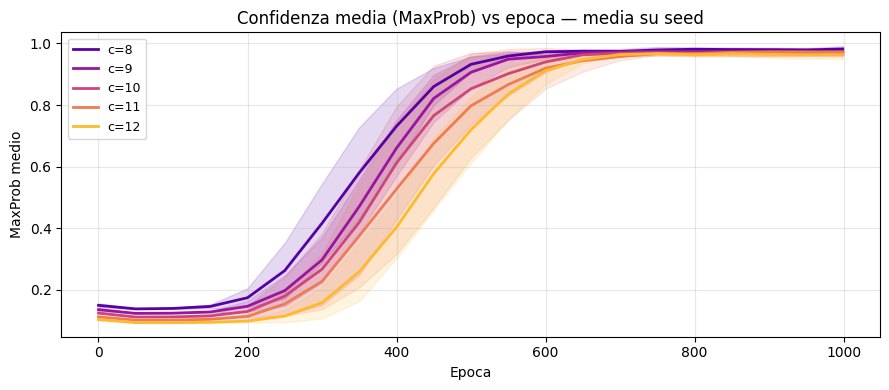

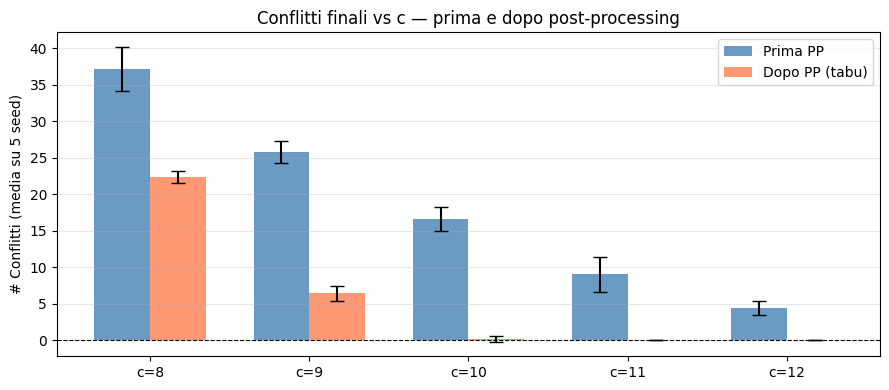

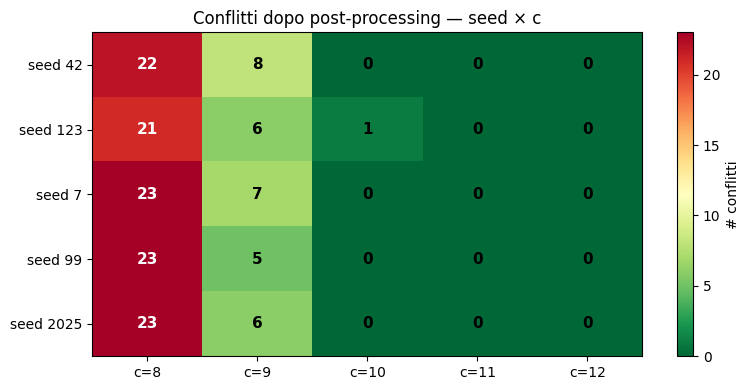

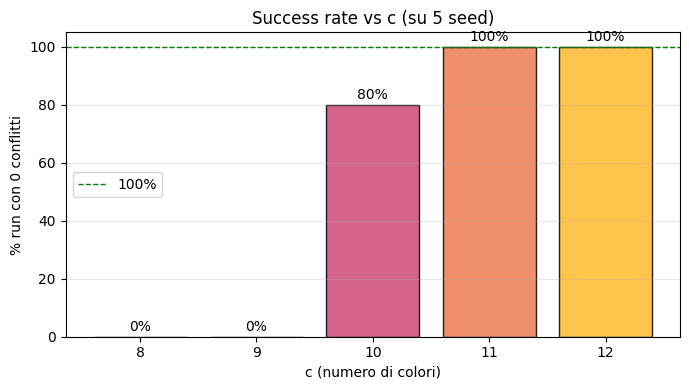


   c |  conf prima PP |  conf dopo PP |  success
──────────────────────────────────────────────────
   8 |   37.2 ± 3.0   |  22.4 ± 0.8   |      0%
   9 |   25.8 ± 1.5   |   6.4 ± 1.0   |      0%
  10 |   16.6 ± 1.6   |   0.2 ± 0.4   |     80%
  11 |    9.0 ± 2.4   |   0.0 ± 0.0   |    100%
  12 |    4.4 ± 1.0   |   0.0 ± 0.0   |    100%


In [27]:
# ═══════════════════════════════════════════════════════════════════════
#  GRAFICI
# ═══════════════════════════════════════════════════════════════════════
SEED_COLORS = plt.cm.tab10(np.linspace(0, 0.45, len(SEEDS)))
C_PALETTE   = plt.cm.plasma(np.linspace(0.15, 0.85, len(C_VALUES)))

def extract_curves(c, seed, field_idx):
    """field_idx: 1=loss_tot, 2=potts, 3=conf, 4=maxP"""
    log = all_results_queen[c][seed]['log']
    epochs = [r[0] for r in log]
    vals   = [r[field_idx] for r in log]
    return epochs, vals


# ────────────────────────────────────────────────────────────────────
#  FIG 1 — Curve di conflitti durante il training (c in colonne)
# ────────────────────────────────────────────────────────────────────
fig1, axes1 = plt.subplots(1, len(C_VALUES), figsize=(18, 4), sharey=False)
fig1.suptitle("Conflitti durante il training per c e seed diversi", fontsize=13, y=1.01)

for ax, c in zip(axes1, C_VALUES):
    for i, seed in enumerate(SEEDS):
        ep, conf = extract_curves(c, seed, 3)
        ax.plot(ep, conf, color=SEED_COLORS[i], lw=1.5, label=f"seed {seed}")
    ax.set_title(f"c = {c}", fontsize=11)
    ax.set_xlabel("Epoca")
    ax.set_ylabel("# Conflitti" if c == C_VALUES[0] else "")
    ax.set_yscale('log')
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.grid(True, alpha=0.3)

legend_elements = [Line2D([0],[0], color=SEED_COLORS[i], lw=2, label=f"seed {s}")
                   for i, s in enumerate(SEEDS)]
fig1.legend(handles=legend_elements, loc='upper right',
            bbox_to_anchor=(1.0, 1.0), fontsize=9)
plt.tight_layout()
plt.show()


# ────────────────────────────────────────────────────────────────────
#  FIG 2 — Curve di loss (Potts) durante il training
# ────────────────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, len(C_VALUES), figsize=(18, 4), sharey=False)
fig2.suptitle("Loss Potts durante il training per c e seed diversi", fontsize=13, y=1.01)

for ax, c in zip(axes2, C_VALUES):
    for i, seed in enumerate(SEEDS):
        ep, potts = extract_curves(c, seed, 2)
        ax.plot(ep, potts, color=SEED_COLORS[i], lw=1.5)
    ax.set_title(f"c = {c}", fontsize=11)
    ax.set_xlabel("Epoca")
    ax.set_ylabel("Potts loss" if c == C_VALUES[0] else "")
    ax.grid(True, alpha=0.3)

fig2.legend(handles=legend_elements, loc='upper right',
            bbox_to_anchor=(1.0, 1.0), fontsize=9)
plt.tight_layout()
plt.show()


# ────────────────────────────────────────────────────────────────────
#  FIG 3 — MaxProb medio vs epoch (confidenza della rete)
# ────────────────────────────────────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(9, 4))
ax3.set_title("Confidenza media (MaxProb) vs epoca — media su seed", fontsize=12)

for j, c in enumerate(C_VALUES):
    all_ep = [r[0] for r in all_results_queen[c][SEEDS[0]]['log']]
    matrix = np.array([[extract_curves(c, s, 4)[1] for s in SEEDS]])
    matrix = matrix.reshape(len(SEEDS), len(all_ep))
    mean   = matrix.mean(axis=0)
    std    = matrix.std(axis=0)
    ax3.plot(all_ep, mean, color=C_PALETTE[j], lw=2, label=f"c={c}")
    ax3.fill_between(all_ep, mean - std, mean + std,
                     color=C_PALETTE[j], alpha=0.15)

ax3.set_xlabel("Epoca"); ax3.set_ylabel("MaxProb medio")
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


# ────────────────────────────────────────────────────────────────────
#  FIG 4 — Conflitti finali prima e dopo post-processing (media ± std)
# ────────────────────────────────────────────────────────────────────
before_mean, before_std = [], []
after_mean,  after_std  = [], []

for c in C_VALUES:
    bef = [all_results_queen[c][s]['conf_before_pp'] for s in SEEDS]
    aft = [all_results_queen[c][s]['conf_after_pp']  for s in SEEDS]
    before_mean.append(np.mean(bef)); before_std.append(np.std(bef))
    after_mean.append(np.mean(aft));  after_std.append(np.std(aft))

x    = np.arange(len(C_VALUES))
w    = 0.35
fig4, ax4 = plt.subplots(figsize=(9, 4))
ax4.set_title("Conflitti finali vs c — prima e dopo post-processing", fontsize=12)

ax4.bar(x - w/2, before_mean, w, yerr=before_std, capsize=5,
        color='steelblue', alpha=0.8, label='Prima PP')
ax4.bar(x + w/2, after_mean,  w, yerr=after_std,  capsize=5,
        color='coral',     alpha=0.8, label='Dopo PP (tabu)')

ax4.set_xticks(x); ax4.set_xticklabels([f"c={c}" for c in C_VALUES])
ax4.set_ylabel("# Conflitti (media su 5 seed)")
ax4.axhline(0, color='black', lw=0.8, ls='--')
ax4.legend(); ax4.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()


# ────────────────────────────────────────────────────────────────────
#  FIG 5 — Heatmap seed × c (conflitti dopo PP)
# ────────────────────────────────────────────────────────────────────
heatmap = np.array([[all_results_queen[c][s]['conf_after_pp']
                     for c in C_VALUES] for s in SEEDS])

fig5, ax5 = plt.subplots(figsize=(8, 4))
im = ax5.imshow(heatmap, cmap='RdYlGn_r', aspect='auto',
                vmin=0, vmax=max(1, heatmap.max()))

for i in range(len(SEEDS)):
    for j in range(len(C_VALUES)):
        v = heatmap[i, j]
        ax5.text(j, i, str(v), ha='center', va='center',
                 fontsize=11, fontweight='bold',
                 color='white' if v > heatmap.max() * 0.5 else 'black')

ax5.set_xticks(range(len(C_VALUES))); ax5.set_xticklabels([f"c={c}" for c in C_VALUES])
ax5.set_yticks(range(len(SEEDS)));   ax5.set_yticklabels([f"seed {s}" for s in SEEDS])
ax5.set_title("Conflitti dopo post-processing — seed × c", fontsize=12)
plt.colorbar(im, ax=ax5, label="# conflitti")
plt.tight_layout(); plt.show()


# ────────────────────────────────────────────────────────────────────
#  FIG 6 — Success rate vs c (frequenza di 0 conflitti)
# ────────────────────────────────────────────────────────────────────
success_rate = []
for c in C_VALUES:
    rate = sum(1 for s in SEEDS if all_results_queen[c][s]['conf_after_pp'] == 0) / len(SEEDS)
    success_rate.append(rate * 100)

fig6, ax6 = plt.subplots(figsize=(7, 4))
ax6.bar(C_VALUES, success_rate, color=C_PALETTE, alpha=0.85, edgecolor='black')
ax6.set_xlabel("c (numero di colori)"); ax6.set_ylabel("% run con 0 conflitti")
ax6.set_title("Success rate vs c (su 5 seed)", fontsize=12)
ax6.set_ylim(0, 105); ax6.set_xticks(C_VALUES)
ax6.axhline(100, color='green', lw=1, ls='--', label='100%')
for i, (cv, sr) in enumerate(zip(C_VALUES, success_rate)):
    ax6.text(cv, sr + 2, f"{sr:.0f}%", ha='center', fontsize=10)
ax6.grid(True, alpha=0.3, axis='y'); ax6.legend()
plt.tight_layout(); plt.show()


# ────────────────────────────────────────────────────────────────────
#  TABELLA RIASSUNTIVA
# ────────────────────────────────────────────────────────────────────
print(f"\n{'c':>4} | {'conf prima PP':>14} | {'conf dopo PP':>13} | {'success':>8}")
print("─" * 50)
for i, c in enumerate(C_VALUES):
    bef = [all_results_queen[c][s]['conf_before_pp'] for s in SEEDS]
    aft = [all_results_queen[c][s]['conf_after_pp']  for s in SEEDS]
    sr  = success_rate[i]
    print(f"{c:>4} | "
          f"{np.mean(bef):>6.1f} ± {np.std(bef):<5.1f} | "
          f"{np.mean(aft):>5.1f} ± {np.std(aft):<5.1f} | "
          f"{sr:>6.0f}%")

# Miles750

In [28]:
universal_seed(42)
seed=42

Seed impostato su 42


In [29]:
print(df_g17) #connessione vuol dire vicine entro 750 miglia

      node1  node2
0         1    128
1         1    122
2         1    120
3         1    119
4         1    117
...     ...    ...
4221    128     14
4222    128      8
4223    128      7
4224    128      2
4225    128      1

[4226 rows x 2 columns]


In [30]:
unique, counts = np.unique(df_g17['node1'].values, return_counts=True)  # non cambierebbe nulla se operassi invece su node2 per simmetria
miles_intensity_miles = counts.astype(np.float32)

In [31]:
import networkx as nx #serve poi da togliere

G = nx.Graph()
G.add_edges_from(zip(df_g17['node1'], df_g17['node2']))

pos = nx.spring_layout(G, seed=seed) #stampa mantenendo le distanze con posizioni casuali

In [32]:
import collections

od = collections.OrderedDict(sorted(pos.items()))  #ordina dizionario dalle keys
od_keys = []
od_vals = []
for k, v in od.items():
  od_keys.append(k)
  od_vals.append(v)

od_vals = np.array(od_vals) #dizionario con posizioni farlocche di tutti i nodi (x,y)
#print(od_vals)
#od_keys è in struttura uguale a unique

In [33]:
class MilesGraphGenerator(Dataset):
    def __init__(self, X, df, coords, AUGMENT=False):
        self.X = X
        self.df = df
        self.coords = coords
        self.AUGMENT = AUGMENT

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        intensity = self.X.copy()
        node_list = self.df.copy()
        coords_sim = self.coords.copy()
        col1_label = (self.df.columns)[0]
        col2_label = (self.df.columns)[1]

        edge_index_raw = build_edges_from_df(node_list[col1_label]-1, node_list[col2_label]-1)
        num_nodes = len(intensity)

        '''
        Augmentation con stessa filosofia di queen9x9, ma adesso non voglio ruotare
        secondo il gruppo di simmetria: essendo i nodi liberi, ovvero non dipendenti
        dalle posizioni ma dalle connessioni, mi concentro sul generalizzare il grafo
        permutando, con l'obiettivo di non incorrere in minimi come prima.
        '''

        if self.AUGMENT:
            perm = torch.randperm(num_nodes)  # rimescolamento degli indici
            intensity = intensity[perm]
            coords_sim = coords_sim[perm]
            #Rimappo gli archi affinché puntino ai nuovi indici
            reverse_perm = torch.empty_like(perm)
            reverse_perm[perm] = torch.arange(num_nodes)
            edge_index = reverse_perm[edge_index_raw]
        else:
            edge_index = edge_index_raw

        pos = torch.tensor(coords_sim, dtype=torch.float)
        p_min, p_max = pos.min(), pos.max()
        pos_n = ((pos - p_min) / (p_max - p_min + 1e-7)) * 2. - 1.

        val_t = torch.tensor(intensity / (intensity.sum() + 1e-7), dtype=torch.float).view(-1, 1)

        x = torch.cat([val_t, pos_n], dim=1)

        return Data(x=x, edge_index=edge_index, y=None, pos=pos_n)

In [34]:
# N e batches da definire nell'allenamento
miles_df = df_g17.copy()
N = 1 # randomizzerò 800 volte per epoca, sullo stesso grafo di partenza
multi_X = [miles_intensity_miles] * N
multi_df = [miles_df] * N
multi_od_vals = [od_vals] * N

miles_dataset_miles = MilesGraphGenerator(miles_intensity_miles, miles_df, od_vals, AUGMENT=False)
miles_loader_miles = DataLoader(miles_dataset_miles, batch_size=int(N), shuffle=True)

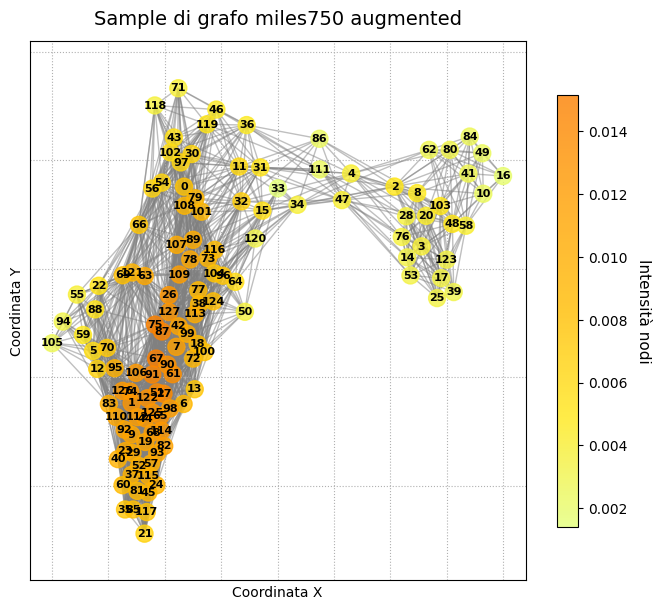

In [35]:
from torch_geometric.data import Data
from torch_geometric.utils import to_networkx

data = miles_dataset_miles[0]
G = to_networkx(data, to_undirected=True)
pos_dict = {i: data.pos[i].numpy() for i in range(128)}

fig, ax = plt.subplots(figsize=(8, 7))

nodes = nx.draw_networkx_nodes(
    G, pos_dict,
    ax=ax,
    node_size=150,
    node_color=data.x[:, 0].numpy(),
    cmap='Wistia',
    alpha=0.8
)

nx.draw_networkx_edges(G, pos_dict, ax=ax, alpha=0.5, edge_color="gray")
nx.draw_networkx_labels(G, pos_dict, ax=ax, font_size=8, font_weight='bold')

cbar = fig.colorbar(nodes, shrink = 0.8, ax=ax)
cbar.set_label('Intensità nodi', rotation=270, labelpad=17, fontsize=11)

x_coords = data.pos[:, 0].numpy()
ax.set_xlim(x_coords.min() - 0.1, x_coords.max() + 0.1)
ax.grid(True, linestyle=':', alpha=1.0)

ax.set_title("Sample di grafo miles750 augmented", fontsize=14, pad=12)
ax.set_xlabel("Coordinata X", fontsize=10)
ax.set_ylabel("Coordinata Y", fontsize=10)

plt.show()

In [36]:
##@title Muovi il cursore per filtrare o cambiare il valore { run: "auto" }

# Definisci la variabile, l'intervallo [min, max] e lo step
c = 31 #@param {type:"slider", min:28, max:35, step:1}

print(f"Il valore selezionato è: {c}")

Il valore selezionato è: 31


In [37]:


class GNN_Miles750_Net(nn.Module):
    def __init__(self, num_colors=c, num_nodes=128, i_dim=3):
        """
        Modello GNN ottimizzato per la colorazione del grafo Miles750 Augmented.

        Args:
            num_colors (int): Numero di canali di output (c), idealmente >= 31.
            num_nodes (int): Numero totale di nodi univoci nel grafo (N).
            i_dim (int): Feature geometriche in ingresso (es. Coordinata X, Coordinata Y, Intensità).
        """
        super().__init__()

        self.N = num_nodes

        # Embedding strutturale per identificare univocamente i nodi nelle cricche dense.
        # Per 128 nodi, un embedding da 32 o 64 dimensioni è ideale.
        self.node_emb = nn.Embedding(num_nodes, 64)

        # Aumentiamo leggermente la capacità dei canali nascosti (da 64 a 128)
        # dato che miles750 ha densità e interconnessioni molto elevate nella zona centrale.
        self.conv1 = SAGEConv(i_dim+64, 128)
        self.conv2 = SAGEConv(128, 128)
        self.conv3 = SAGEConv(128, 128)
        self.conv4 = SAGEConv(128, 128)

        # Uno strato lineare finale per mappare le feature nei "c" colori disponibili
        self.fc = nn.Linear(128 + 64, num_colors)



    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        # Genera gli ID dei nodi tenendo conto di eventuali minibatch.
        # Nota: assicurati che data.num_nodes rifletta il numero effettivo di nodi nel batch.
        node_ids = torch.arange(
            data.num_nodes,
            device=x.device) % self.N


        # Recupera l'embedding posizionale
        emb = self.node_emb(node_ids)

        # Concatenazione delle feature geometriche (X, Y, intensità) con l'embedding
        h = torch.cat([x, emb], dim=-1)

        # Passaggi di Message Passing con GraphSAGE

        h1 = F.relu(self.conv1(h, edge_index))
        h2 = F.relu(self.conv2(h1, edge_index)) +h1
        h3 = F.relu(self.conv3(h2, edge_index)) +h2
        h4 = F.relu(self.conv4(h3, edge_index))+h3

        out = torch.cat([h4,emb], dim= -1 )

        # Calcolo dei logits per la classificazione del colore
        logits = self.fc(out)

        # Se usi CrossEntropyLoss durante il training, ricordati che PyTorch
        # preferisce ricevere i LOGITS grezzi. Se invece ti serve la distribuzione
        # di probabilità esplicita, tieni il Softmax.
        return logits

In [38]:
model = GNN_Miles750_Net().to(device) #abbiamo esperienza di casi con 12 colori e 0 conflitti
print(model)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Numero di parametri trainabili:", num_params)

GNN_Miles750_Net(
  (node_emb): Embedding(128, 64)
  (conv1): SAGEConv(67, 128, aggr=mean)
  (conv2): SAGEConv(128, 128, aggr=mean)
  (conv3): SAGEConv(128, 128, aggr=mean)
  (conv4): SAGEConv(128, 128, aggr=mean)
  (fc): Linear(in_features=192, out_features=31, bias=True)
)
Numero di parametri trainabili: 130143


In [39]:
def potts_loss(p, edge_index):
    row, col = edge_index
    mask = row < col # evita doppio conteggio
    row, col = row[mask], col[mask]
    conflict_prob = (p[row] * p[col]).sum(dim=1)

    return conflict_prob.mean()

def entropy_loss(p):
  return -(p*torch.log(p+1e-9)).sum(dim=1).mean()

def count_conflicts(colors, edge_index):
    row, col = edge_index
    mask = row < col
    row, col = row[mask], col[mask]
    return (colors[row] == colors[col]).sum().item()

In [40]:
#  CORRECT (PyTorch Geometric)
from torch_geometric.loader import DataLoader

batch = next(iter(miles_loader_miles))
batch = batch.to(device) # sposta tutti i tensori della Batch PyG sulla device

logits= model(batch)
p = F.softmax(logits, dim =-1)

print('output shape: ', p.shape)
print('num grafi nella batch: ', batch.num_graphs)
print('num nodi nella batch: ', batch.num_nodes)

# loss
loss = potts_loss(p, data.edge_index)

print('loss: ', loss.item()) #.item() per prendere il numero, sarebbe un tensore

colors = p.argmax(dim=1)
conflicts = count_conflicts(colors, batch.edge_index)
print('numero di conflitti: ', conflicts) #da dividere per batch_size

output shape:  torch.Size([128, 31])
num grafi nella batch:  1
num nodi nella batch:  128
loss:  0.037042029201984406
numero di conflitti:  248


In [41]:
model=GNN_Miles750_Net(num_colors=c, num_nodes=batch.num_nodes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.002, weight_decay = 1e-6)
num_epochs= 2000
best_conflicts = 10**9
best_logits= None
for epoch in range(num_epochs):
        optimizer.zero_grad()
        logits = model(batch)

        temp = max(0.04, 2.5 * (0.9995 ** epoch))
        p = F.softmax(logits/temp , dim=-1)


        potts = potts_loss(p,batch.edge_index)
        ent = entropy_loss(p)

        #entropy weitght cresce col tempo
        ent_w = min(0.025, epoch / 8000 * 0.025)

        loss = potts + ent_w * ent

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()


        if epoch % 100 == 0:
            colors = logits.argmax(dim=1)
            conflicts = count_conflicts(colors, batch.edge_index)
            if conflicts < best_conflicts:
                best_conflicts = conflicts
                best_logits = logits.detach().clone()
            print(epoch, f"Loss Tot: {loss.item():.4f}", f"Potts: {potts.item():.4f}", f"Conf: {conflicts}", f"MaxProb: {max_prob:.4f}",  f"Best_conf: {best_conflicts:.0f}")

0 Loss Tot: 0.0329 Potts: 0.0329 Conf: 526 MaxProb: 0.9608 Best_conf: 526
100 Loss Tot: 0.0027 Potts: 0.0027 Conf: 4 MaxProb: 0.9608 Best_conf: 4
200 Loss Tot: 0.0019 Potts: 0.0019 Conf: 4 MaxProb: 0.9608 Best_conf: 4
300 Loss Tot: 0.0019 Potts: 0.0019 Conf: 4 MaxProb: 0.9608 Best_conf: 4
400 Loss Tot: 0.0019 Potts: 0.0019 Conf: 4 MaxProb: 0.9608 Best_conf: 4
500 Loss Tot: 0.0019 Potts: 0.0019 Conf: 4 MaxProb: 0.9608 Best_conf: 4
600 Loss Tot: 0.0019 Potts: 0.0019 Conf: 4 MaxProb: 0.9608 Best_conf: 4
700 Loss Tot: 0.0019 Potts: 0.0019 Conf: 4 MaxProb: 0.9608 Best_conf: 4
800 Loss Tot: 0.0019 Potts: 0.0019 Conf: 4 MaxProb: 0.9608 Best_conf: 4
900 Loss Tot: 0.0019 Potts: 0.0019 Conf: 4 MaxProb: 0.9608 Best_conf: 4
1000 Loss Tot: 0.0019 Potts: 0.0019 Conf: 4 MaxProb: 0.9608 Best_conf: 4
1100 Loss Tot: 0.0019 Potts: 0.0019 Conf: 4 MaxProb: 0.9608 Best_conf: 4
1200 Loss Tot: 0.0019 Potts: 0.0019 Conf: 4 MaxProb: 0.9608 Best_conf: 4
1300 Loss Tot: 0.0019 Potts: 0.0019 Conf: 4 MaxProb: 0.9608

## Post Processing

In [42]:
def repair_with_escape(edge_index, num_nodes, num_colors, init_colors,
                       max_steps=300000, patience=3000):
    row, col = edge_index
    mask = row < col
    row, col = row[mask], col[mask]
    device = edge_index.device

    colors = init_colors.clone()
    best_colors = colors.clone()
    best_conf = 10**9
    stuck = 0

    def count():
        return (colors[row] == colors[col]).sum().item()

    for step in range(max_steps):
        conf_edges = colors[row] == colors[col]
        n_conf = conf_edges.sum().item()

        if n_conf < best_conf:
            best_conf = n_conf
            best_colors = colors.clone()
            stuck = 0
            print("step", step, "best", best_conf)

        if n_conf == 0:
            print("RISOLTO", step)
            return colors

        stuck += 1

        bad_nodes = torch.cat([row[conf_edges], col[conf_edges]]).unique()

        # se bloccato a 1, perturba anche vicini dei nodi conflittuali
        if stuck > patience:
            neighs = []
            for v in bad_nodes:
                neighs.append(col[row == v])
                neighs.append(row[col == v])
            neighs = torch.cat(neighs).unique()

            pool = torch.cat([bad_nodes, neighs]).unique()

            k = min(5, len(pool))
            chosen = pool[torch.randperm(len(pool), device=device)[:k]]
            colors[chosen] = torch.randint(num_colors, (k,), device=device)

            stuck = 0
            continue

        # mossa min-conflicts normale
        v = bad_nodes[torch.randint(len(bad_nodes), (1,), device=device)].item()

        neighbors = torch.cat([
            col[row == v],
            row[col == v]
        ])

        best_c = colors[v].item()
        best_local = 10**9

        for c in torch.randperm(num_colors, device=device):
            c = c.item()
            local_conf = (colors[neighbors] == c).sum().item()

            if local_conf < best_local:
                best_local = local_conf
                best_c = c

        colors[v] = best_c

    print("Non risolto. Migliore:", best_conf)
    return best_colors

In [43]:
colors = repair_with_escape(
    batch.edge_index,
    num_nodes=batch.num_nodes,
    num_colors=c,
    init_colors=best_logits.argmax(dim=1),
    max_steps=100000,
    patience=2000
)

print(count_conflicts(colors, batch.edge_index))




step 0 best 4
step 9 best 3
step 699 best 2
step 3090 best 1
step 27511 best 0
RISOLTO 27511
0


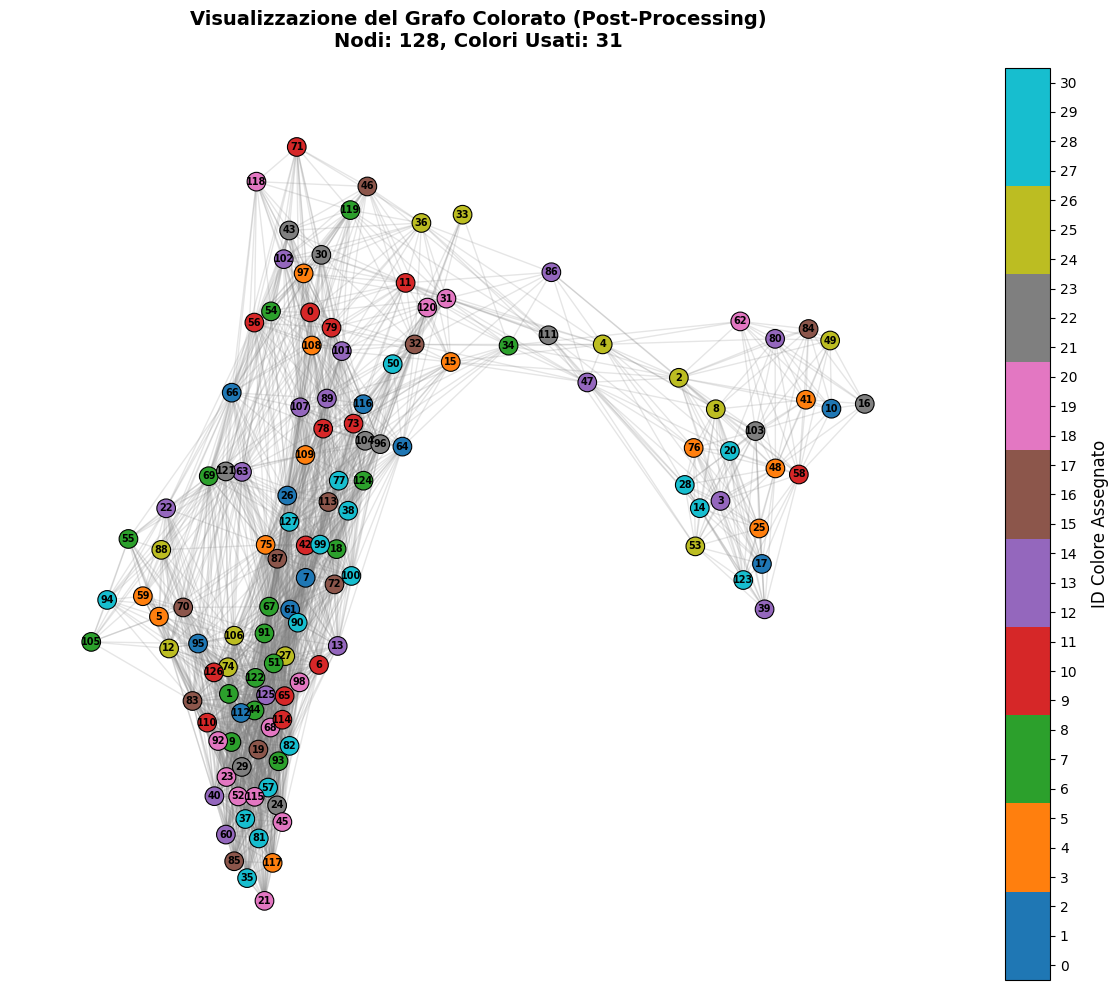

In [44]:
# 1. Convertiamo l'edge_index di PyTorch Geometric in un grafo NetworkX
# Estraiamo gli archi e li portiamo sulla CPU come array numpy
edge_index_np = batch.edge_index.cpu().numpy()
edges = list(zip(edge_index_np[0], edge_index_np[1]))

G = nx.Graph()
G.add_edges_from(edges)

# Assicuriamoci che tutti i nodi siano presenti (anche eventuali nodi isolati)
num_nodes = batch.num_nodes
G.add_nodes_from(range(num_nodes))

# 2. Prepariamo i colori dei nodi generati dal PP
# Portiamo il tensore dei colori sulla CPU
colors_np = colors.cpu().numpy() if hasattr(colors, 'cpu') else np.array(colors)

# Usiamo una colormap qualitativa e accattivante (es. 'tab10', 'Set2' o 'rainbow')
# In questo modo ogni ID numerico del colore corrisponderà a una tinta ben distinta
cmap = plt.get_cmap('tab10', int(colors_np.max() + 1))

# 3. Calcoliamo un layout "fatto bene" e pulito
plt.figure(figsize=(12, 10), dpi=100)
plt.title(f"Visualizzazione del Grafo Colorato (Post-Processing)\nNodi: {num_nodes}, Colori Usati: {len(np.unique(colors_np))}", 
          fontsize=14, fontweight='bold', pad=15)

# Il layout spring (Fruchterman-Reingold) distanzia i nodi in base alle connessioni.
# Modificando 'k' (distanza ottimale) e 'iterations' si ottiene un disegno molto pulito ed ordinato.
pos = nx.spring_layout(G, k=1.5/np.sqrt(num_nodes), iterations=50, seed=42)

# 4. Disegniamo gli archi con una leggera trasparenza per non appesantire la vista
nx.draw_networkx_edges(G, pos, alpha=0.2, edge_color='gray', width=1.0)

# 5. Disegniamo i nodi colorati
node_draw = nx.draw_networkx_nodes(G, pos, 
                                   node_color=colors_np, 
                                   cmap=cmap, 
                                   node_size=180, 
                                   edgecolors='black', # Bordo nero per far risaltare i nodi
                                   linewidths=0.8)

# 6. Disegniamo le etichette dei nodi (opzionale, utile se i nodi non sono tantissimi)
if num_nodes <= 150:
    nx.draw_networkx_labels(G, pos, font_size=7, font_color='black', font_weight='bold')

# Aggiungiamo una barra dei colori laterale (colorbar) per mostrare la mappatura delle classi/colori
cbar = plt.colorbar(node_draw, ticks=np.unique(colors_np), boundaries=np.arange(colors_np.min()-0.5, colors_np.max()+1.5, 1))
cbar.set_label('ID Colore Assegnato', fontsize=12, labelpad=10)
cbar.ax.tick_params(labelsize=10)

plt.axis('off') # Nascondiamo gli assi cartesiani per pulizia grafica
plt.tight_layout()
plt.show()

In [45]:
#Setup valori 
C_VALUES   = list(range(29, 34))   
SEEDS      = [42, 123, 7, 99, 2025]
N_EPOCHS   = 2000
LOG_EVERY  = 100
N_AUG      = 1    # copie augmentate per loader
BATCH_SIZE = 1
MILES_PATIENCE = 2000
MILES_ITER_PP = 10000

Save_Data = True #se Treu genera file con dati salvati !!attenzione sovrascrive se i file esistono gia

In [46]:
# Studio condizioni iniziali — Miles750
# Usa le funzioni definite nelle celle precedenti:
#   - universal_seed
#   - MilesGraphGenerator
#   - GNN_Miles750_Net
#   - potts_loss / entropy_loss / count_conflicts
#   - repair_with_escape come post-processing (PP)

all_results_miles = {c: {} for c in C_VALUES}
total_runs_miles  = len(C_VALUES) * len(SEEDS)
run_idx_miles      = 0

# Generiamo il dataset di riferimento una sola volta fuori dai cicli
base_dataset = MilesGraphGenerator(miles_intensity_miles, miles_df, od_vals, AUGMENT=False)
# Estraiamo il singolo grafo (l'oggetto Data di PyG)
graph_ref = base_dataset[0]
MILES_NUM_NODES = graph_ref.num_nodes

print(f"Miles750: num_nodes={MILES_NUM_NODES}, ITER_PP={MILES_ITER_PP}, PATIENCE={MILES_PATIENCE}")

for c in C_VALUES:
    for seed in SEEDS:
        run_idx_miles += 1
        print(f"\n{'═'*58}")
        print(f"   Run {run_idx_miles}/{total_runs_miles}  |  c={c}  seed={seed}")
        print(f"{'═'*58}")

        # ── riproducibilità ──────────────────────────────────────────
        universal_seed(seed)

        # ── caricamento grafo unico sul device ───────────────────────
        # Spostato qui: carichiamo in VRAM una volta sola per questa run
        batch = graph_ref.to(device)

        # ── modello ──────────────────────────────────────────────────
        model_run = GNN_Miles750_Net(num_colors=c, num_nodes=MILES_NUM_NODES).to(device)
        optimizer = torch.optim.Adam(model_run.parameters(), lr=0.002, weight_decay=1e-6)
        model_run.train()

        # log: (epoch, loss_tot, potts, n_conflicts, max_prob, best_conf)
        log = []
        t0 = time.time()
        best_conf_miles = float("inf")
        best_model_state_miles = None

        for epoch in range(N_EPOCHS):
            optimizer.zero_grad()

            logits = model_run(batch)

            # Softmax con temperatura decrescente
            temp = max(0.04, 2.5 * (0.9995 ** epoch))
            prob = F.softmax(logits / temp, dim=-1)

            potts = potts_loss(prob, batch.edge_index)
            ent = entropy_loss(prob)

            # Peso entropia crescente
            ent_w = min(0.025, epoch / 8000 * 0.025)
            loss = potts + ent_w * ent

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_run.parameters(), 1.0)
            optimizer.step()

            # ── logging e controllo conflitti (allineato a LOG_EVERY) ──
            if epoch % LOG_EVERY == 0 or epoch == N_EPOCHS - 1:
                with torch.no_grad():
                    colors_b = logits.argmax(dim=1)
                    conf_b = count_conflicts(colors_b, batch.edge_index)
                    max_prob = prob.max(dim=1).values.mean().item()

                if conf_b < best_conf_miles:
                    best_conf_miles = conf_b
                    # deepcopy viene eseguito solo quando c'è un effettivo miglioramento
                    best_model_state_miles = copy.deepcopy(model_run.state_dict())

                log.append((epoch, loss.item(), potts.item(), conf_b, max_prob, best_conf_miles))

                if epoch % 500 == 0 or epoch == N_EPOCHS - 1:
                    print(f"   ep {epoch:4d} | loss {loss.item():.4f} "
                          f"| potts {potts.item():.4f} "
                          f"| conf {conf_b:4d} "
                          f"| maxP {max_prob:.3f} "
                          f"| best {best_conf_miles:.0f}")

                # ── early stopping ──────────────────────────────────
                if conf_b == 0:
                    print(f"   ✅ 0 conflitti raggiunti all'epoca {epoch} — stop anticipato")
                    break

        # Carica i pesi migliori trovati nella run
        if best_model_state_miles is not None:
            model_run.load_state_dict(best_model_state_miles)
            print(f"   📥 Caricato il miglior modello della run (conflitti minimi nel train: {best_conf_miles})")

        # ── valutazione su grafo singolo (no augment) ─────────────────
        model_run.eval()
        with torch.no_grad():
            # Il batch è già sul device ed è aggiornato
            logits_eval = model_run(batch)
            colors_raw = logits_eval.argmax(dim=1).cpu()
            ei_cpu = batch.edge_index.cpu()

        conf_before = count_conflicts(colors_raw, ei_cpu)

        # ── post-processing / PP ──────────────────────────────────────
        if conf_before == 0:
            colors_fixed, conf_after = colors_raw, 0
            print("   ⚡ 0 conflitti — post-processing saltato")
        else:
            colors_fixed = repair_with_escape(
                edge_index=ei_cpu,
                num_nodes=MILES_NUM_NODES,
                num_colors=c,
                init_colors=colors_raw,
                max_steps=MILES_ITER_PP,
                patience=MILES_PATIENCE
            )
            conf_after = count_conflicts(colors_fixed, ei_cpu)

        elapsed = time.time() - t0

        print(f"\n   ✔  {elapsed:.1f}s  |  "
              f"conflitti: {conf_before} → {conf_after} (dopo PP)")

        all_results_miles[c][seed] = {
            "log": log,
            "conf_before_pp": conf_before,
            "conf_after_pp": conf_after,
            "colors": colors_fixed,
            "time_s": elapsed,
        }

print("\nRun Miles completate!!")

if Save_Data:
    with open("Risultati_Finale_miles.csv", "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["C_Value", "Seed", "Conf_Before_PP", "Conf_After_PP", "Time_Seconds"])

        for c, seeds in all_results_miles.items():
            for seed, res in seeds.items():
                writer.writerow([c, seed, res["conf_before_pp"], res["conf_after_pp"], res["time_s"]])

    print("💾 Risultati Miles salvati correttamente in 'Risultati_Finale_miles.csv'")

Miles750: num_nodes=128, ITER_PP=10000, PATIENCE=2000

══════════════════════════════════════════════════════════
   Run 1/25  |  c=29  seed=42
══════════════════════════════════════════════════════════
Seed impostato su 42
   ep    0 | loss 0.0352 | potts 0.0352 | conf  178 | maxP 0.051 | best 178
   ep  500 | loss 0.0047 | potts 0.0047 | conf   10 | maxP 1.000 | best 10
   ep 1000 | loss 0.0047 | potts 0.0047 | conf   10 | maxP 1.000 | best 10
   ep 1500 | loss 0.0047 | potts 0.0047 | conf   10 | maxP 1.000 | best 10
   ep 1999 | loss 0.0047 | potts 0.0047 | conf   10 | maxP 1.000 | best 10
   📥 Caricato il miglior modello della run (conflitti minimi nel train: 10)
step 0 best 10
step 5 best 9
step 18 best 8
step 39 best 7
step 54 best 6
step 280 best 5
step 470 best 4
step 595 best 3
step 6176 best 2
Non risolto. Migliore: 2

   ✔  17.2s  |  conflitti: 10 → 2 (dopo PP)

══════════════════════════════════════════════════════════
   Run 2/25  |  c=29  seed=123
════════════════════════

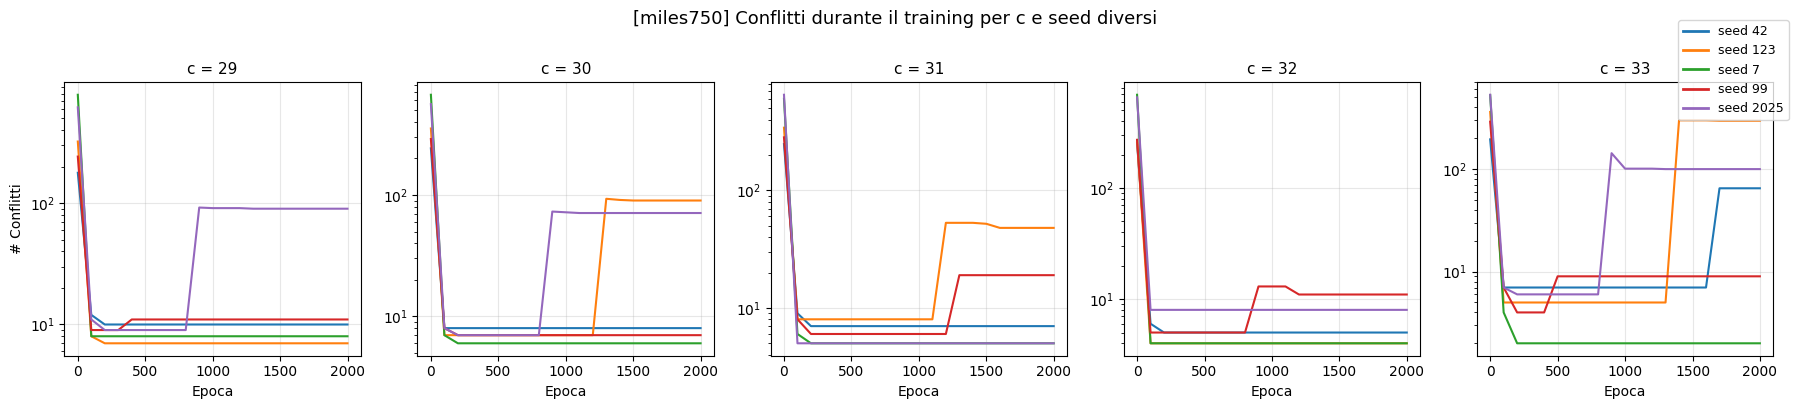

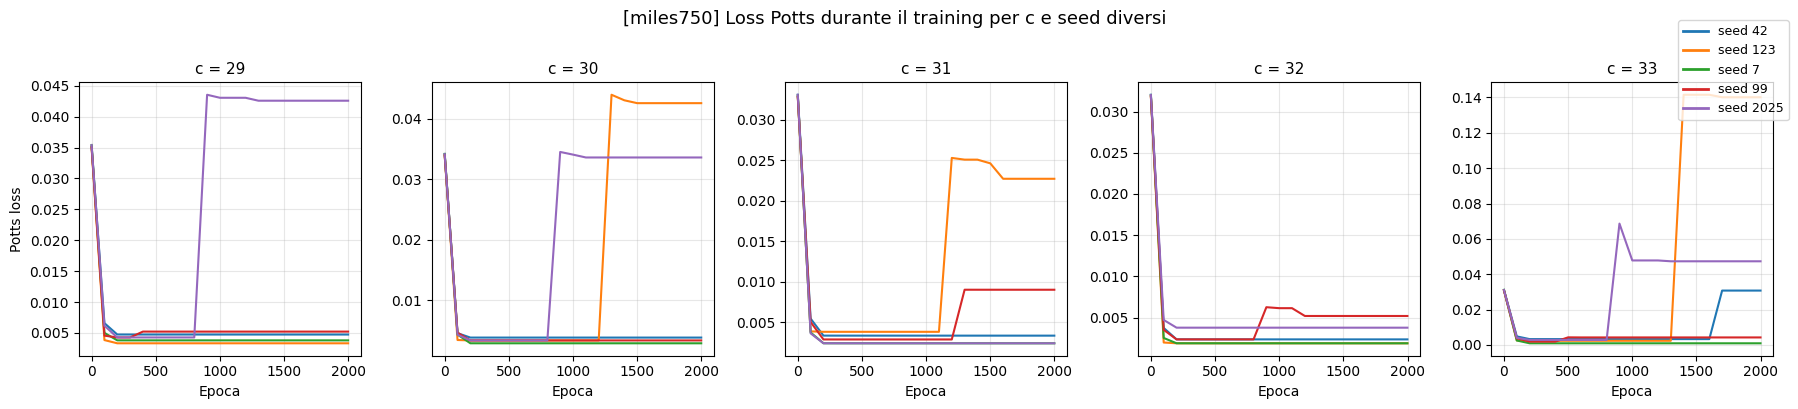

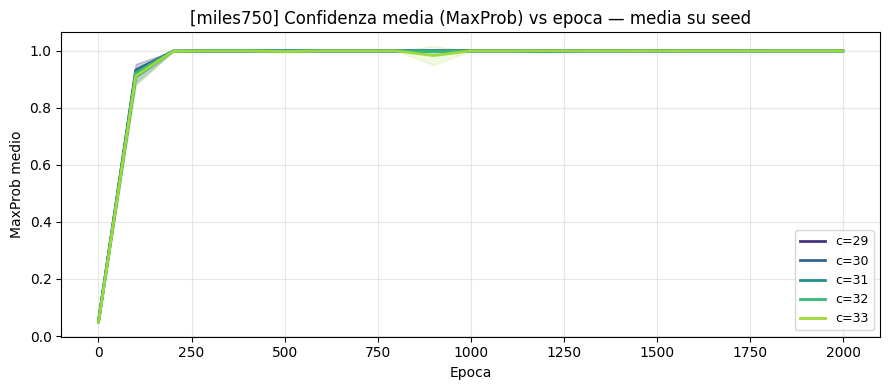

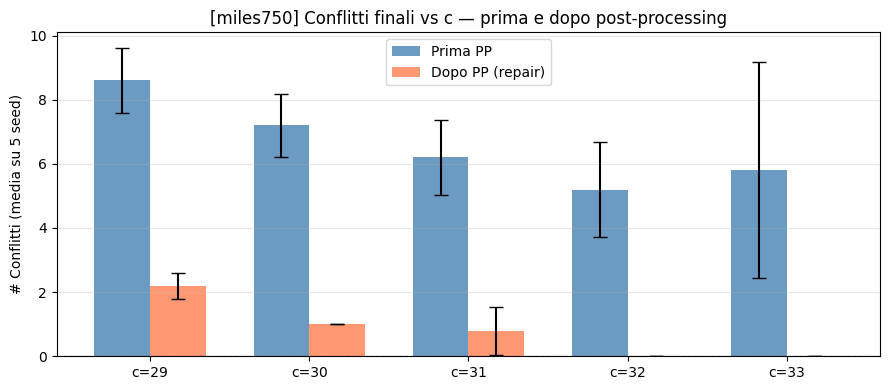

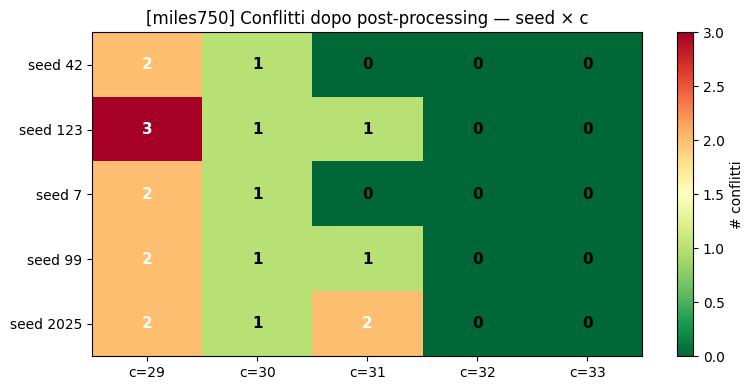

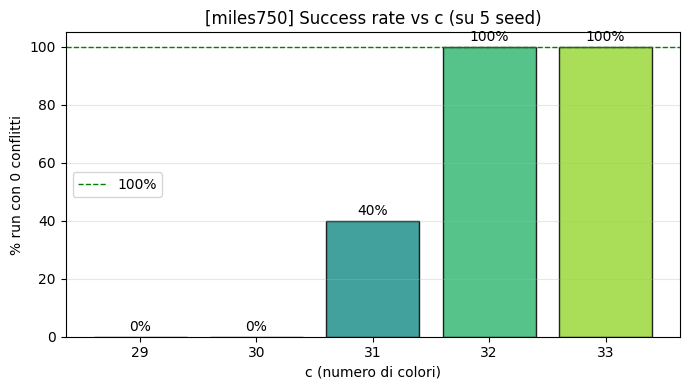


   c |  conf prima PP |  conf dopo PP |  success
──────────────────────────────────────────────────
  29 |    8.6 ± 1.0   |   2.2 ± 0.4   |      0%
  30 |    7.2 ± 1.0   |   1.0 ± 0.0   |      0%
  31 |    6.2 ± 1.2   |   0.8 ± 0.7   |     40%
  32 |    5.2 ± 1.5   |   0.0 ± 0.0   |    100%
  33 |    5.8 ± 3.4   |   0.0 ± 0.0   |    100%


In [47]:
# ═══════════════════════════════════════════════════════════════════════
#  GRAFICI — miles750
# ═══════════════════════════════════════════════════════════════════════
SEED_COLORS_MILES = plt.cm.tab10(np.linspace(0, 0.45, len(SEEDS)))
C_PALETTE_MILES   = plt.cm.viridis(np.linspace(0.15, 0.85, len(C_VALUES)))

def extract_curves_miles(c, seed, field_idx):
    """field_idx: 1=loss_tot, 2=potts, 3=conf, 4=maxP"""
    log = all_results_miles[c][seed]['log']
    epochs = [r[0] for r in log]
    vals   = [r[field_idx] for r in log]
    return epochs, vals


# ────────────────────────────────────────────────────────────────────
#  FIG 1 — Curve di conflitti durante il training (c in colonne)
# ────────────────────────────────────────────────────────────────────
fig1, axes1 = plt.subplots(1, len(C_VALUES), figsize=(18, 4), sharey=False)
fig1.suptitle("[miles750] Conflitti durante il training per c e seed diversi", fontsize=13, y=1.01)

for ax, c in zip(axes1, C_VALUES):
    for i, seed in enumerate(SEEDS):
        ep, conf = extract_curves_miles(c, seed, 3)
        ax.plot(ep, conf, color=SEED_COLORS_MILES[i], lw=1.5, label=f"seed {seed}")
    ax.set_title(f"c = {c}", fontsize=11)
    ax.set_xlabel("Epoca")
    ax.set_ylabel("# Conflitti" if c == C_VALUES[0] else "")
    ax.set_yscale('log')
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.grid(True, alpha=0.3)

legend_elements_miles = [Line2D([0],[0], color=SEED_COLORS_MILES[i], lw=2, label=f"seed {s}")
                         for i, s in enumerate(SEEDS)]
fig1.legend(handles=legend_elements_miles, loc='upper right',
            bbox_to_anchor=(1.0, 1.0), fontsize=9)
plt.tight_layout()
plt.show()


# ────────────────────────────────────────────────────────────────────
#  FIG 2 — Curve di loss (Potts) durante il training
# ────────────────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, len(C_VALUES), figsize=(18, 4), sharey=False)
fig2.suptitle("[miles750] Loss Potts durante il training per c e seed diversi", fontsize=13, y=1.01)

for ax, c in zip(axes2, C_VALUES):
    for i, seed in enumerate(SEEDS):
        ep, potts = extract_curves_miles(c, seed, 2)
        ax.plot(ep, potts, color=SEED_COLORS_MILES[i], lw=1.5)
    ax.set_title(f"c = {c}", fontsize=11)
    ax.set_xlabel("Epoca")
    ax.set_ylabel("Potts loss" if c == C_VALUES[0] else "")
    ax.grid(True, alpha=0.3)

fig2.legend(handles=legend_elements_miles, loc='upper right',
            bbox_to_anchor=(1.0, 1.0), fontsize=9)
plt.tight_layout()
plt.show()


# ────────────────────────────────────────────────────────────────────
#  FIG 3 — MaxProb medio vs epoch (confidenza della rete)
# ────────────────────────────────────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(9, 4))
ax3.set_title("[miles750] Confidenza media (MaxProb) vs epoca — media su seed", fontsize=12)

for j, c in enumerate(C_VALUES):
    all_ep = [r[0] for r in all_results_miles[c][SEEDS[0]]['log']]
    matrix = np.array([[extract_curves_miles(c, s, 4)[1] for s in SEEDS]])
    matrix = matrix.reshape(len(SEEDS), len(all_ep))
    mean   = matrix.mean(axis=0)
    std    = matrix.std(axis=0)
    ax3.plot(all_ep, mean, color=C_PALETTE_MILES[j], lw=2, label=f"c={c}")
    ax3.fill_between(all_ep, mean - std, mean + std,
                     color=C_PALETTE_MILES[j], alpha=0.15)

ax3.set_xlabel("Epoca"); ax3.set_ylabel("MaxProb medio")
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


# ────────────────────────────────────────────────────────────────────
#  FIG 4 — Conflitti finali prima e dopo post-processing (media ± std)
# ────────────────────────────────────────────────────────────────────
before_mean_miles, before_std_miles = [], []
after_mean_miles,  after_std_miles  = [], []

for c in C_VALUES:
    bef = [all_results_miles[c][s]['conf_before_pp'] for s in SEEDS]
    aft = [all_results_miles[c][s]['conf_after_pp']  for s in SEEDS]
    before_mean_miles.append(np.mean(bef)); before_std_miles.append(np.std(bef))
    after_mean_miles.append(np.mean(aft));  after_std_miles.append(np.std(aft))

x    = np.arange(len(C_VALUES))
w    = 0.35
fig4, ax4 = plt.subplots(figsize=(9, 4))
ax4.set_title("[miles750] Conflitti finali vs c — prima e dopo post-processing", fontsize=12)

ax4.bar(x - w/2, before_mean_miles, w, yerr=before_std_miles, capsize=5,
        color='steelblue', alpha=0.8, label='Prima PP')
ax4.bar(x + w/2, after_mean_miles,  w, yerr=after_std_miles,  capsize=5,
        color='coral',     alpha=0.8, label='Dopo PP (repair)')

ax4.set_xticks(x); ax4.set_xticklabels([f"c={c}" for c in C_VALUES])
ax4.set_ylabel("# Conflitti (media su 5 seed)")
ax4.axhline(0, color='black', lw=0.8, ls='--')
ax4.legend(); ax4.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()


# ────────────────────────────────────────────────────────────────────
#  FIG 5 — Heatmap seed × c (conflitti dopo PP)
# ────────────────────────────────────────────────────────────────────
heatmap_miles = np.array([[all_results_miles[c][s]['conf_after_pp']
                           for c in C_VALUES] for s in SEEDS])

fig5, ax5 = plt.subplots(figsize=(8, 4))
im = ax5.imshow(heatmap_miles, cmap='RdYlGn_r', aspect='auto',
                vmin=0, vmax=max(1, heatmap_miles.max()))

for i in range(len(SEEDS)):
    for j in range(len(C_VALUES)):
        v = heatmap_miles[i, j]
        ax5.text(j, i, str(v), ha='center', va='center',
                 fontsize=11, fontweight='bold',
                 color='white' if v > heatmap_miles.max() * 0.5 else 'black')

ax5.set_xticks(range(len(C_VALUES))); ax5.set_xticklabels([f"c={c}" for c in C_VALUES])
ax5.set_yticks(range(len(SEEDS)));   ax5.set_yticklabels([f"seed {s}" for s in SEEDS])
ax5.set_title("[miles750] Conflitti dopo post-processing — seed × c", fontsize=12)
plt.colorbar(im, ax=ax5, label="# conflitti")
plt.tight_layout(); plt.show()


# ────────────────────────────────────────────────────────────────────
#  FIG 6 — Success rate vs c (frequenza di 0 conflitti)
# ────────────────────────────────────────────────────────────────────
success_rate_miles = []
for c in C_VALUES:
    rate = sum(1 for s in SEEDS if all_results_miles[c][s]['conf_after_pp'] == 0) / len(SEEDS)
    success_rate_miles.append(rate * 100)

fig6, ax6 = plt.subplots(figsize=(7, 4))
ax6.bar(C_VALUES, success_rate_miles, color=C_PALETTE_MILES, alpha=0.85, edgecolor='black')
ax6.set_xlabel("c (numero di colori)"); ax6.set_ylabel("% run con 0 conflitti")
ax6.set_title("[miles750] Success rate vs c (su 5 seed)", fontsize=12)
ax6.set_ylim(0, 105); ax6.set_xticks(C_VALUES)
ax6.axhline(100, color='green', lw=1, ls='--', label='100%')
for i, (cv, sr) in enumerate(zip(C_VALUES, success_rate_miles)):
    ax6.text(cv, sr + 2, f"{sr:.0f}%", ha='center', fontsize=10)
ax6.grid(True, alpha=0.3, axis='y'); ax6.legend()
plt.tight_layout(); plt.show()


# ────────────────────────────────────────────────────────────────────
#  TABELLA RIASSUNTIVA
# ────────────────────────────────────────────────────────────────────
print(f"\n{'c':>4} | {'conf prima PP':>14} | {'conf dopo PP':>13} | {'success':>8}")
print("─" * 50)
for i, c in enumerate(C_VALUES):
    bef = [all_results_miles[c][s]['conf_before_pp'] for s in SEEDS]
    aft = [all_results_miles[c][s]['conf_after_pp']  for s in SEEDS]
    sr  = success_rate_miles[i]
    print(f"{c:>4} | "
          f"{np.mean(bef):>6.1f} ± {np.std(bef):<5.1f} | "
          f"{np.mean(aft):>5.1f} ± {np.std(aft):<5.1f} | "
          f"{sr:>6.0f}%")
